# Student Engagement & Retention Analysis

## Objective
Analyze student behavior in an EdTech product to understand:
- retention patterns
- engagement impact
- dropout drivers

## Dataset
Simulated dataset with ~20 students across 6 weeks.
Includes engagement metrics, activity, and final status.

In [35]:
import pandas as pd

df = pd.read_csv(r'/Users/anastasia/Downloads/data - Лист1.csv')
df.head()
# или
# df = pd.read_csv('/Users/anastasia/Downloads/data - Лист1.csv')

,student_id,group,grade_level,week,lessons_attended,homework_done_pct,platform_activity,questions_asked,mock_score,engagement_index,dropout,drop/act,final status
0,S001,OGE_4,9,1,1,"0,42",8,0,"2,00","0,42",0,Active,NaN
1,S002,OGE_4,9,1,1,"0,30",5,0,"2,00","0,30",1,Dropout,NaN
2,S003,OGE_4,9,1,1,"0,50",10,1,"3,00","0,50",0,Active,NaN
3,S004,OGE_4,9,1,1,"0,60",14,2,"4,00","0,60",0,Active,NaN
4,S101,OGE_5,9,1,1,"0,82",22,3,"5,00","0,82",1,Dropout,NaN


## Data Preparation

- Checked data types  
- No missing values found  
- Engagement index scaled from 0–100  

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   student_id         94 non-null     object
 1   group              94 non-null     object
 2   grade_level        94 non-null     int64 
 3   week               94 non-null     int64 
 4   lessons_attended   94 non-null     int64 
 5   homework_done_pct  94 non-null     object
 6   platform_activity  94 non-null     int64 
 7   questions_asked    94 non-null     int64 
 8   mock_score         94 non-null     object
 9   engagement_index   94 non-null     object
 10  dropout            94 non-null     int64 
 11  drop/act           94 non-null     object
 12  final status       22 non-null     object
dtypes: int64(6), object(7)
memory usage: 9.7+ KB


## Retention Analysis

We analyze how many users remain active over time.

Retention is a key metric for product health.

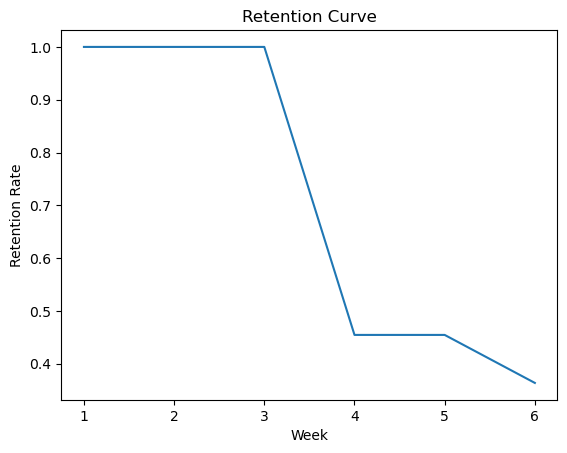

In [37]:
retention = df.groupby('week')['student_id'].nunique()

retention_rate = retention / retention.iloc[0]

plt.plot(retention_rate)
plt.title('Retention Curve')
plt.xlabel('Week')
plt.ylabel('Retention Rate')
plt.show()

### Insight

Retention remains stable in the first 3 weeks, then drops significantly.

This suggests a potential issue with mid-term engagement or value delivery.

## Funnel Analysis

We track user progression through the learning journey.

22 22 10


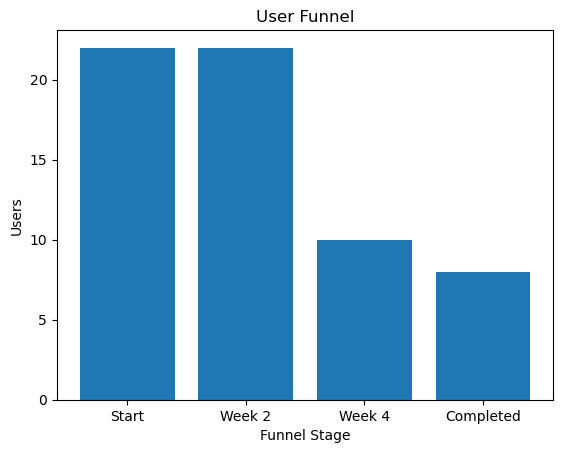

In [38]:
### Funnel
total = df['student_id'].nunique()
week2 = df[df['week'] >= 2]['student_id'].nunique()
week4 = df[df['week'] >= 4]['student_id'].nunique()

print(total, week2, week4)

plt.bar(steps, users)
plt.xlabel("Funnel Stage")
plt.ylabel("Users")
plt.title("User Funnel")
plt.show()

### Insight

Significant drop-off occurs before Week 4.

This indicates friction in the early learning experience.

## Engagement Segmentation

Users are grouped based on engagement levels.

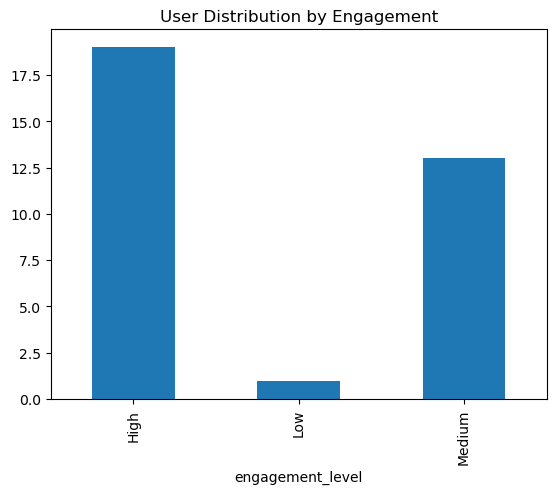

In [48]:
def segment(x):
    if x >= 0.70:
        return 'High'
    elif x >= 0.40:
        return 'Medium'
    return 'Low'

df['engagement_level'] = df['engagement_index'].apply(segment)
engagement = df.groupby('engagement_level')['student_id'].nunique()
engagement.plot(kind='bar')
plt.title('User Distribution by Engagement')
plt.show()

### Insight

Most users fall into Medium and High engagement groups,
but this does not guarantee retention.

## Dropout Analysis

We analyze how engagement impacts dropout probability.

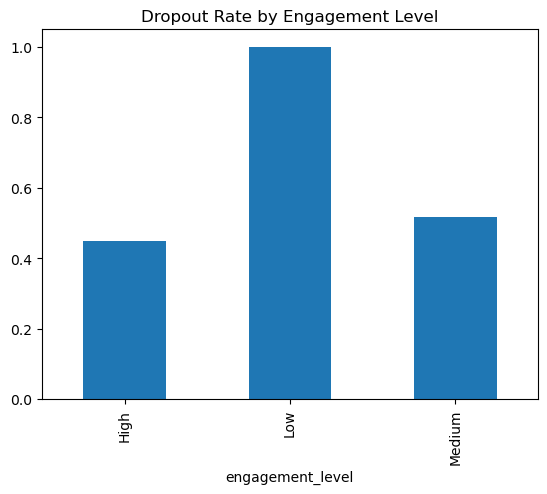

In [49]:
dropout = df.groupby('engagement_level')['dropout'].mean()
dropout.plot(kind='bar')
plt.title('Dropout Rate by Engagement Level')
plt.show()

### Key Insight

Even highly engaged users drop out at a high rate.

This suggests that engagement alone is not enough —
product value or long-term motivation may be missing.



## Final Insights

- Critical drop-off after Week 4  
- Low engagement users always churn  
- High engagement does not guarantee retention  

## Recommendations

- Improve onboarding experience  
- Add progress tracking  
- Introduce engagement nudges  